# Lecture 5 — Permutations, Transpose, and Vector Spaces
Instructor: Gilbert Strang

## 1. Permutation Matrices

When we perform row exchanges during elimination, we are not just “swapping rows.”
We are multiplying by a special matrix.

That matrix is called a **permutation matrix**.

A permutation matrix P is:

- The identity matrix
- With its rows reordered

Example (3×3):

Identity:
[[1 0 0],
 [0 1 0],
 [0 0 1]]

Swap row 1 and row 2:

P =
[[0 1 0],
 [1 0 0],
 [0 0 1]]

Multiplying P * A swaps the corresponding rows of A.

So row exchange is not an operation outside linear algebra —
it is just matrix multiplication.

---

### Why do we need permutation matrices?

During elimination, if a pivot is zero, we must swap rows.

Instead of saying “we swapped rows,” we write:

P A = L U

This means:

1. First permute the rows using P
2. Then perform elimination to get L and U

So LU factorization in practice is really:

P A = L U

---

### Structure of P

A permutation matrix has:

- Exactly one 1 in each row
- Exactly one 1 in each column
- All other entries are 0

There are n! different permutation matrices of size n×n.

n! = n × (n−1) × (n−2) × ... × 1

This counts all possible row reorderings.

---

### Important Properties

Permutation matrices are special because:

P inverse = P transpose

P^T P = I

So permutation matrices are orthogonal matrices.

This means:

Swapping rows is reversible,
and undoing a permutation is just transposing P.

### Constructing a Permutation Matrix

A permutation matrix is built from the identity matrix.

To swap rows, we simply reorder the rows of the identity matrix.

This matrix P will act on another matrix A through multiplication.

Multiplying P * A will reorder the rows of A.

In [2]:
import numpy as np
from matplotlib import pyplot as plt

A = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])
print("A:\n", A, "\n\n")

I = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]
])
print("I:\n", I, "\n\n")

P = np.array([
    [0, 1, 0],
    [1, 0, 0],
    [0, 0, 1]
])
print("P:\n", P, "\n\n")

A:
 [[1 2 3]
 [4 5 6]
 [7 8 9]] 


I:
 [[1 0 0]
 [0 1 0]
 [0 0 1]] 


P:
 [[0 1 0]
 [1 0 0]
 [0 0 1]] 




### Inverse of a Permutation

If a permutation reorders rows, there must be a way to undo it.

We test whether the transpose of P acts as its inverse.

If P^T P = I, then:

P^T = P^-1

This would mean permutation matrices are orthogonal.

In [3]:
PA = P @ A
print("PA:\n", PA, "\n\n")

PT = P.T
print("PT:\n", PT, "\n\n")

PTP = PT @ P
print("PTP:\n", PTP, "\n\n")

PPT = P @ PT
print("PPT:\n", PPT, "\n\n")


PA:
 [[4 5 6]
 [1 2 3]
 [7 8 9]] 


PT:
 [[0 1 0]
 [1 0 0]
 [0 0 1]] 


PTP:
 [[1 0 0]
 [0 1 0]
 [0 0 1]] 


PPT:
 [[1 0 0]
 [0 1 0]
 [0 0 1]] 




### Verifying Row Exchange

After computing P * A, we observe that the rows of A were reordered.

This confirms:

Row exchange is equivalent to matrix multiplication.

A permutation matrix does not modify numerical values.
It only rearranges rows.

So swapping rows during elimination is a linear operation.

In [4]:
import itertools

v = [0, 1, 2]
perms = itertools.permutations(v)
all_perms = list(perms)
print(all_perms)

[(0, 1, 2), (0, 2, 1), (1, 0, 2), (1, 2, 0), (2, 0, 1), (2, 1, 0)]


### Counting Permutations

For a 3×3 matrix, there are 3! = 6 possible row reorderings.

In general, for an n×n matrix:

n! = n × (n−1) × (n−2) × ... × 1

Each possible reordering corresponds to a different permutation matrix.

These matrices represent all possible ways to reorder coordinates in R^n.

In [11]:
v = np.array([2, 0, 1])
print("v:\n", v, "\n\n")

zeros = np.zeros((len(v), len(v)))
print("zeros:\n", zeros, "\n\n")

for i in range(len(v)):
    zeros[i, v[i]] = 1

print("zeros after add:\n", zeros, "\n\n")


v:
 [2 0 1] 


zeros:
 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]] 


zeros after add:
 [[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]] 




In [12]:
P = zeros
print("P:\n", P, "\n\n")

PA = P @ A
print("PA:\n", PA, "\n\n")

P:
 [[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]] 


PA:
 [[7. 8. 9.]
 [1. 2. 3.]
 [4. 5. 6.]] 




### Interpretation — What We Learned About Permutations

From the numerical experiments, we confirmed:

1. Multiplying P * A reorders the rows of A.
2. P^T = P^-1.
3. P^T P = I.

This means a permutation matrix represents a reversible reordering of coordinates.

It does not change lengths or geometry.
It only rearranges structure.

This explains why, in elimination with pivoting, we write:

P A = L U

The permutation happens first,
then elimination proceeds normally.

So row exchange is not an external trick —
it is a linear transformation.

## 2. Transpose

The transpose of a matrix switches rows and columns.

Definition:

(A^T)i,j = A j,i

This means:

Entry in row i, column j of A^T
comes from row j, column i of A.

So transpose reflects a matrix across its main diagonal.

Rows become columns.
Columns become rows.

Transpose does not change the numbers.
It changes how we interpret them.

In [13]:
R = np.array([
    [1, 3],
    [2, 3],
    [4, 1]
])
print("R:\n", R, "\n\n")



R:
 [[1 3]
 [2 3]
 [4 1]] 




### Observing the Structure of R

Matrix R has:

- 3 rows
- 2 columns

Its columns are:

First column: (1, 2, 4)
Second column: (3, 3, 1)

So the columns of R live in R^3.

Transpose will convert these columns into rows.

In [14]:
R_T = R.T
print("R_T:\n", R_T, "\n\n")

R_T:
 [[1 2 4]
 [3 3 1]] 




### Understanding the Transpose

After computing R^T, we observe:

Rows of R became columns of R^T.
Columns of R became rows of R^T.

Original size: 3×2
Transposed size: 2×3

Transpose switches dimensions.

It reflects the matrix across its diagonal.

### R^T R and Symmetry

Transpose has a powerful structural consequence.

For any matrix R, the matrix R^T R is always symmetric.

Why?

Take the transpose:

(R^T R)^T
= R^T (R^T)^T
= R^T R

Because:

(A^T)^T = A

So R^T R equals its own transpose.

This means R^T R is symmetric.

We now verify this numerically.

In [16]:
M = R_T @ R
print("M:\n", M, "\n\n")

M_T = M.T
print("M_T:\n", M_T, "\n\n")

M:
 [[21 13]
 [13 19]] 


M_T:
 [[21 13]
 [13 19]] 




### Interpretation

We confirmed numerically that:

R^T R = (R^T R)^T

So it is symmetric.

Geometrically, R^T R measures interactions between columns of R.

Diagonal entries:
dot product of each column with itself.

Off-diagonal entries:
dot products between different columns.

So symmetry comes from the symmetry of the dot product.

Transpose is not just flipping a matrix.
It connects linear algebra with geometry.

## 3. Vector Spaces and R^n

A vector space is a collection of vectors where we can:

- Add vectors
- Multiply vectors by scalars
- Form linear combinations

And after doing those operations,
we must remain inside the same set.

This “staying inside” property is essential.

If adding or scaling pushes us outside the set,
then it is not a vector space.

---

### R^2, R^3, R^n

R^2:
All 2-dimensional vectors with real numbers.
Geometrically: the entire x–y plane.

R^3:
All 3-dimensional vectors with real numbers.
Geometrically: the full 3D space.

R^n:
All column vectors with n real components.

These spaces are the basic examples of vector spaces.

They contain the zero vector.
They are closed under addition.
They are closed under scalar multiplication.

### Example of a Set That Is NOT a Vector Space

Consider the first quadrant in R^2:

All vectors (x, y) where x ≥ 0 and y ≥ 0.

This set allows addition of positive vectors.

But it fails one essential property:

Closure under scalar multiplication.

If we multiply a vector by a negative number,
we leave the set.

So the first quadrant is not a vector space.

In [17]:
v = np.array([2, 3])
print("v:\n", v, "\n\n")

v_1 = v * -1
print("v_1:\n", v_1, "\n\n")

v:
 [2 3] 


v_1:
 [-2 -3] 




### Subspaces of R^2

A subspace is a smaller vector space inside a larger one.

To be a subspace of R^2, a set must:

1) Contain the zero vector
2) Be closed under addition
3) Be closed under scalar multiplication

In R^2, there are only three types of subspaces:

1) The entire plane R^2
2) Any line that passes through the origin
3) The zero vector alone

Lines that do not pass through the origin are not subspaces.

### Visualizing Subspaces in R^2

A line in R^2 is a subspace only if it passes through the origin.

Why?

Because scalar multiplication must keep us on the line.

If the line does not pass through (0, 0),
multiplying by zero moves us off the line.

So the zero vector must belong to every subspace.

In [22]:
import matplotlib.pyplot as plt
x = np.linspace(-5, 5, 100)
y = 2 * x
print("first five points y values: \n", y[:5])


first five points y values: 
 [-10.          -9.7979798   -9.5959596   -9.39393939  -9.19191919]


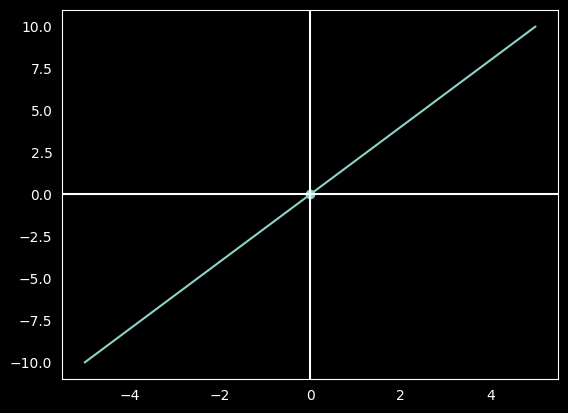

In [23]:
plt.figure()
plt.plot(x, y)
plt.scatter(0, 0)
plt.axhline(0)
plt.axvline(0)
plt.grid()
plt.show()

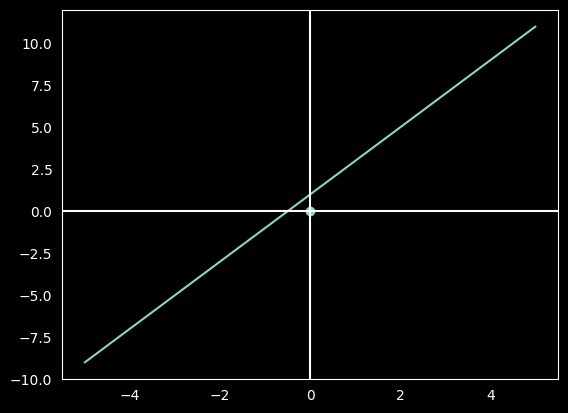

In [24]:
y_bad = (2 * x) + 1
plt.figure()
plt.plot(x, y_bad)
plt.scatter(0, 0)
plt.axhline(0)
plt.axvline(0)
plt.grid()
plt.show()

## 4. Column Space

Given a matrix A, its columns live in R^m (if A is m×n).

All linear combinations of those columns form a subspace.

This subspace is called the column space of A.

If A has two columns in R^3,
their linear combinations form either:

- A line (if columns are multiples), or
- A plane through the origin (if independent)

In [30]:
c1 = R[:, 0]
c2 = R[:, 1]

print("c1:\n", c1, "\n")
print("c2:\n", c2, "\n")

c1:
 [1 2 4] 

c2:
 [3 3 1] 



### Visualizing the Columns in R^3

The columns of R are vectors in R^3.

We will draw:

- c1 as an arrow from the origin
- c2 as an arrow from the origin

Their linear combinations span the column space.

If c1 and c2 are not multiples of each other,
their column space is a plane through the origin.

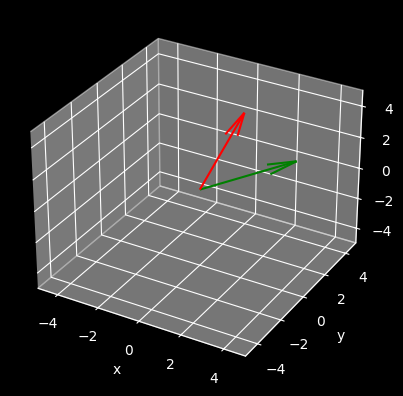

In [32]:
fig=plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.quiver(0,0,0, c1[0], c1[1], c1[2], color='r')
ax.quiver(0,0,0, c2[0], c2[1], c2[2], color='g')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_zlim(-5, 5)
plt.show()

### Generating Linear Combinations

The column space consists of all vectors of the form:

a * c1 + b * c2

where a and b are real numbers.

If c1 and c2 are independent,
these combinations form a plane through the origin.

We now generate many such combinations to visualize the plane.

In [34]:
a = np.linspace(-2, 2, 100)
b = np.linspace(-2, 2, 100)
A_grid, B_grid = np.meshgrid(a, b)
print("A_grid shape: ", A_grid.shape, "\n")
print("B_grid shape: ", B_grid.shape, "\n")

A_grid shape:  (100, 100) 

B_grid shape:  (100, 100) 



In [36]:
X = A_grid * c1[0] + B_grid * c2[0]
Y = A_grid * c1[1] + B_grid * c2[1]
Z = A_grid * c1[2] + B_grid * c2[2]

print("X Shape: ", X.shape)
print("Y Shape: ", Y.shape)
print("Z Shape: ", Z.shape)

X Shape:  (100, 100)
Y Shape:  (100, 100)
Z Shape:  (100, 100)


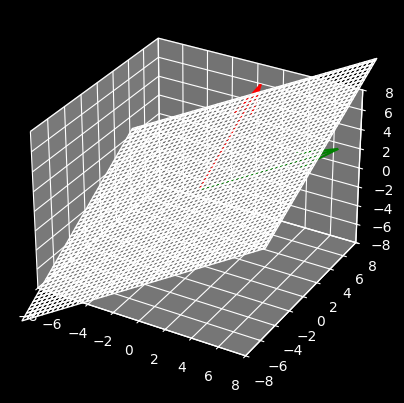

In [49]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, alpha=0.001)
ax.quiver(0, 0, 0, c1[0], c1[1], c1[2], color='r', length=10, normalize=True)
ax.quiver(0, 0, 0, c2[0], c2[1], c2[2], color='g', length=10, normalize=True)
ax.set_xlim(-8, 8)
ax.set_ylim(-8, 8)
ax.set_zlim(-8, 8)
plt.show()

## Conceptual Summary

In this lecture, we moved from computation to structure.

Permutation matrices showed that row exchanges are linear transformations.
They reorder coordinates without changing geometry.

Transpose revealed a deeper symmetry.
R^T R builds a matrix of dot products between columns.
Symmetry comes from geometry, not coincidence.

Vector spaces introduced the idea of closure.
To be a vector space, a set must contain the zero vector
and remain closed under addition and scalar multiplication.

A subspace is simply a smaller vector space inside a larger one.
In R^2, subspaces are:
- the whole plane,
- any line through the origin,
- or the zero vector alone.

Finally, the column space of a matrix is the span of its columns.
For our example matrix, the column space is a plane through the origin in R^3.

Algebra, geometry, and computation all describe the same structure.